In [35]:
#########  price ----------> Bathroom --> improved version ----------------------->

In [36]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [39]:
df = pd.read_csv('MagicBricks.csv')
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [41]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   str    
 4   Locality     1259 non-null   str    
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   str    
 8   Transaction  1259 non-null   str    
 9   Type         1254 non-null   str    
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 108.3 KB


In [42]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [43]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [44]:
## remove missing value

df = df.dropna(subset=['Bathroom','Price'])



In [45]:
df.isnull().sum()

Area             0
BHK              0
Bathroom         0
Furnishing       5
Locality         0
Parking         31
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       239
dtype: int64

In [46]:
### remove duplicates

df = df.drop_duplicates()

In [47]:
## remove invalid bathroom values 

df = df[df['Bathroom']>0]

In [48]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [51]:
## remove outliers

Q1 = df[['Bathroom','Price']].quantile(0.25)  ## 25 percentile 25 percent data below
Q3 = df[['Bathroom','Price']].quantile(0.75)  ## 75 percentile 

IQR = Q3-Q1

df = df[
    ~(((df[['Bathroom', 'Price']] < (Q1 - 1.5 * IQR)) |
       (df[['Bathroom', 'Price']] > (Q3 + 1.5 * IQR))).any(axis=1))
]

In [52]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1253,1200.0,3,3.0,Semi-Furnished,Chittaranjan Park,1.0,16500000,Ready_to_move,Resale,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


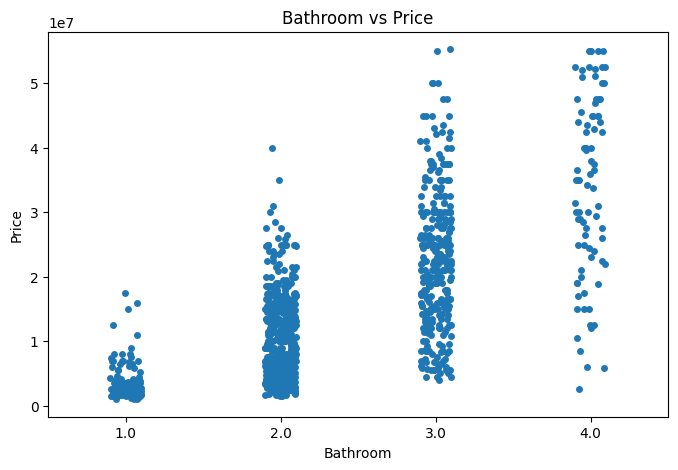

In [53]:
## exploratory data analysis

plt.figure(figsize=(8,5))

sns.stripplot(
    x='Bathroom',
    y='Price',
    data=df,
    jitter=True
)

plt.title('Bathroom vs Price')
plt.show()

In [54]:
## correlation 

correlation = df[['Bathroom','Price']].corr()
print(correlation)

          Bathroom     Price
Bathroom  1.000000  0.704855
Price     0.704855  1.000000


In [55]:
### feautre scaling

x= df[['Bathroom']]
y= df['Price']

In [56]:
### Train _test_split

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
### prediction

y_pred = model.predict(x_test)
print(y_pred)

[21848442.98546423 11460140.28655868 21848442.98546423 11460140.28655868
 21848442.98546423 21848442.98546423  1071837.58765313 11460140.28655868
 21848442.98546423 11460140.28655868 11460140.28655868 11460140.28655868
 21848442.98546423 21848442.98546423 11460140.28655868 21848442.98546423
 11460140.28655868 11460140.28655868 21848442.98546423 11460140.28655868
 11460140.28655868 11460140.28655868 11460140.28655868 21848442.98546423
 11460140.28655868 32236745.68436978 11460140.28655868 11460140.28655868
 21848442.98546423 21848442.98546423  1071837.58765313 11460140.28655868
 21848442.98546423 32236745.68436978 21848442.98546423  1071837.58765313
 11460140.28655868 11460140.28655868 21848442.98546423  1071837.58765313
 11460140.28655868 21848442.98546423 11460140.28655868 32236745.68436978
 11460140.28655868 11460140.28655868 21848442.98546423 11460140.28655868
 21848442.98546423  1071837.58765313 21848442.98546423  1071837.58765313
 21848442.98546423  1071837.58765313  1071837.58765

In [59]:
### custom prediction

sample = pd.DataFrame({'Bathroom':[2]})
predicted_price=model.predict(sample)

print(f"predicted price for 2 Bathrooms:{predicted_price[0]:.2f}")

predicted price for 2 Bathrooms:11460140.29


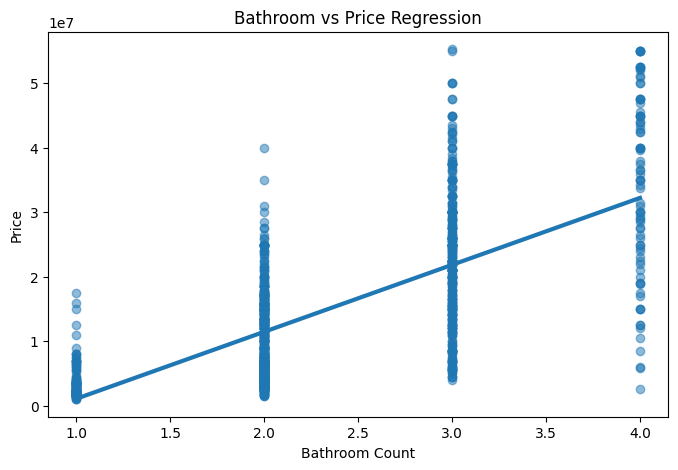

In [60]:
# REGRESSION LINE
# =====================================

sorted_df = df.sort_values(by='Bathroom')

plt.figure(figsize=(8,5))

plt.scatter(df['Bathroom'], df['Price'], alpha=0.5)

plt.plot(
    sorted_df['Bathroom'],
    model.predict(sorted_df[['Bathroom']]),
    linewidth=3
)

plt.xlabel('Bathroom Count')
plt.ylabel('Price')
plt.title('Bathroom vs Price Regression')

plt.show()

In [61]:
# =====================================
# MODEL EVALUATION
# =====================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 6006718.73
MSE  : 60025851611747.55
RMSE : 7747635.23
R2   : 0.5447


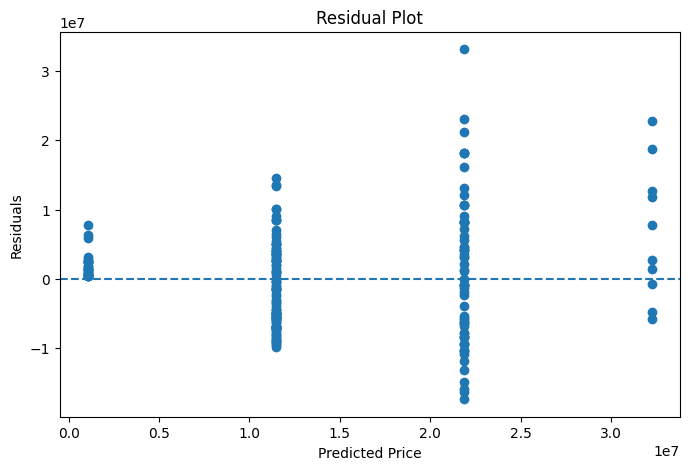

In [62]:
# =====================================
# RESIDUAL ANALYSIS
# =====================================

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

In [64]:
"""Final Analysis
######Strengths
Correct use of regression pipeline
Good beginner-level ML implementation
Proper train-test split concept
Correct use of sklearn regression
######Main Weaknesses
Bathroom alone is weak predictor
Missing preprocessing
Missing outlier handling
Weak visualization choice
Missing residual analysis
Limited interpretation of metrics
####Important ML Understanding

Even if notebook works technically, prediction quality may still be weak because:

real estate prices depend on many features together
single-feature regression oversimplifies the problem"""

'Final Analysis\n######Strengths\nCorrect use of regression pipeline\nGood beginner-level ML implementation\nProper train-test split concept\nCorrect use of sklearn regression\n######Main Weaknesses\nBathroom alone is weak predictor\nMissing preprocessing\nMissing outlier handling\nWeak visualization choice\nMissing residual analysis\nLimited interpretation of metrics\n####Important ML Understanding\n\nEven if notebook works technically, prediction quality may still be weak because:\n\nreal estate prices depend on many features together\nsingle-feature regression oversimplifies the problem'